# Magnetostatic (linear) topology optimisation pareto front

## Setup

### Path setup

In [1]:
import os
path_to_this_folder = os.getcwd() 

### Project setup

In [2]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # Prevent internal ngsolve imports from killing the kernel

### Imports

Usual libraries

In [3]:
import tomllib
from time import time
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tqdm import tqdm
import numpy as np
from netgen.read_gmsh import ReadGmsh
from ngsolve import Mesh, Draw


NeuROM-optim, our in-house library

In [4]:
from neurom_optim.Pre_processing.process_hardware import get_precision, get_device
from neurom_optim.Pre_processing.process_gmsh import read_gmsh, get_nodes_and_elements_IDs
from neurom_optim.FENN.VertexNN.FEENN_2D.FEENN import FEENN_2D
from neurom_optim.FENN.VertexNN.FEENN_2D.Element import Tri_2D_lin
from neurom_optim.FENN.VertexNN.FEENN_2D.Mapping import Mapping_2D_Affine
from neurom_optim.FENN.ConstantNN.constantNN import ConstantNN
from neurom_optim.FENN.L2NN.field_L2NN import Field_L2NN
from neurom_optim.PropertiesNN.PropertiesNN import PropertiesNN
from neurom_optim.Pre_processing.build_solver import build_solver
from neurom_optim.PDE.Magnetostatic_Optim_2D_loss import Magnetostatic_Optim_2D_loss
from neurom_optim.PDE.operators import curl
from neurom_optim.MaterialNN.BinarySelection import BinarySelection
from neurom_optim.Baselines.Poisson_2D.Uniform.baseline import baseline
from neurom_optim.Post_processing.VTKExport.export_vtk import export_vtk

### Number precision

In [5]:
IntPrecision = torch.int32
FloatPrecision = torch.float64

### Hardware

*Note that for cases of small meshes cpu outperforms gpu*

In [6]:
device = 'cpu'

# Problem description

Coils are key elements in electrical circuits. On the one hand, they help smooth the current by drawing energy from its fluctuations and storing it in the magnetic field (example in red in Figure \ref{fig:L_convertisseur}). On the other hand, they enable magnetic coupling by converting the magnetic induction flux passing through them into a voltage via Faraday’s law. Their behavior is directly linked with their inductance value, which we wish to optimize by strategically adding some iron.

The behavior of coils depends directly on their inductance value $L$.
$$
\begin{align*}
\;&L=\frac{\left(N\Phi\right)^2}{\mathcal{E}_m}\\
&\text{Where}\\
&\Phi = \int_S \overrightarrow{B}\cdot\overrightarrow{\text{d}S}&&\text{(Magnetic flux density flux)}\\
&\mathcal{E}m=\frac{1}{2}\int_\Omega \overrightarrow{B}\cdot \overrightarrow{H}\text{d}\Omega&&\text{(Energy stored in the magnetic field)}
\end{align*}
$$

The expression for the inductance indicates that this quantity can be controlled via the number of turns $N$, which amounts to winding more or less conducting wire. However, adding wire increases the component’s resistance and therefore the energy losses due to the Joule effect. At low frequencies, these losses are much smaller if one adjusts $L$ by acting on the magnetic energy $\mathcal{E}_\text{mag}$ that is present in the media through the addition of iron. 



Nevertheless, adding this type of material can increase $L$ only linearly at best, and it significantly increases the weight and volume of the component. While the first point can be offset through trade-offs involving the number of turns, addressing the second requires placing the material efficiently around the coil.

# Focusing on the geometry of the problem

In this toy example, the problem is considered in a simple 2D case. 

In [7]:
interior_dim = 2
boundary_dim = 1

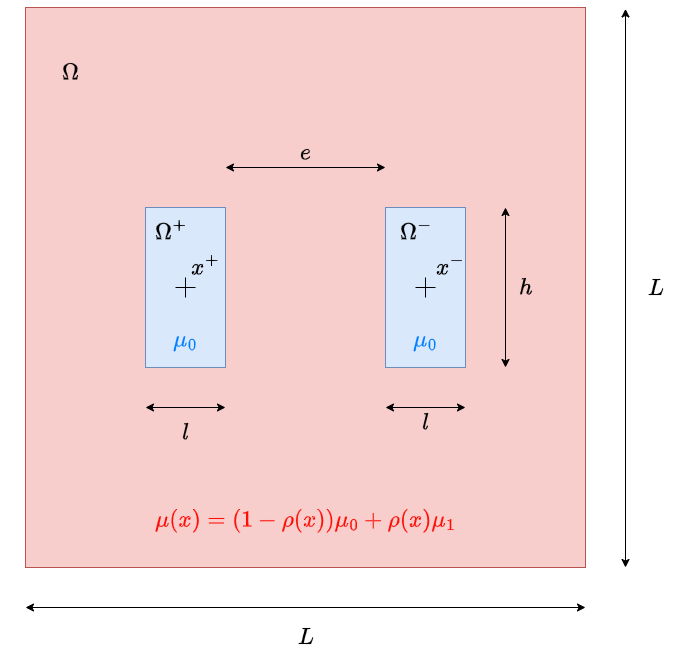

 A slice of a coil is considered, where the center of each coil parts have respectively a positive and negative imposed vector potential value for simulating a magnetic flux. The geometry is registered in the following .msh file.

In [8]:
path_to_msh = os.path.join(path_to_this_folder, "Coil_TC.msh")

The geometry can now be loaded and parsed with the neurom_optim parser

In [9]:
gmsh_mesh = read_gmsh(path_to_msh = path_to_msh,
                      IntPrecision = IntPrecision,
                      FloatPrecision = FloatPrecision)

Nodes = gmsh_mesh.nodes
connectivity = gmsh_mesh.elements[str(interior_dim)]['connectivity']

Processing GMSH file: 100%|██████████| 7984/7984 [00:00<00:00, 103168.07it/s]


# Focusing on the physics-related aspect of the problem

Helmholtz decomposition paired to Maxwell's equation states that the magnetic induction is a field that derives from a vector potential $\overrightarrow{A}\in H\left(\overrightarrow{\text{curl}},\Omega\right)$ such that
$$
\overrightarrow{B}=\overrightarrow{\text{curl}}\left(\overrightarrow{A}\right)
$$

Additionnally, the magnetic excitation is linked to the magnetic induction through the media's physics. In the considered case the physics is linear, so
$$
\overrightarrow{H}=\nu\overrightarrow{B}
$$
Where $\nu$ is a media related quantity known as reluctivity (or magnetic resistivity). More on $\nu$ will be done in the media definition part.

The magnetic energy can be written in term of the vector potential as :
$$
\mathcal{E}_\text{mag}\left(\overrightarrow{A}\right) = \frac{1}{2}\int_\Omega \nu\cdot \overrightarrow{\text{curl}}\left(\overrightarrow{A}\right)\cdot\overrightarrow{\text{curl}}\left(\overrightarrow{A}\right)\text{d}\Omega
$$

Hence, the first step into modelling the magnetic energy is to define a proper vector potential. In the consider problem, the vector potential has the following constrains :
$$
\begin{align*}
&\overrightarrow{A} = A(x)\overrightarrow{e}_z&&\forall x\in \Omega\\
&\overrightarrow{A}(x^+)\cdot \overrightarrow{e}_z=A_0\\
&\overrightarrow{A}(x^-)\cdot \overrightarrow{e}_z = -A_0\\
&\overrightarrow{A}(x) = \overrightarrow{0}&&\forall x\in\partial \Omega\\
\end{align*}
$$ 

In a practicle setting, $\overrightarrow{A}$ is approximated through a finite element scheme. Here we use a triangle mesh with pointwise linear interpolation (Lagrange P1). Therefore, $\mathcal{E}_{mag}$ is expressed through the integration of a constant by element field, which can be computed exactly using an order 1 Gauss quadrature.

In [10]:
quadrature_order = 1

This can directly be built using neurom_optim 

In [11]:
def build_field_candidate():
    global gmsh_mesh, Nodes, connectivity, dirichlet_config, interior_dim, boundary_dim, IntPrecision, FloatPrecision, n_components, quadrature_order, device

    n_components = 1

    dirichlet_exterior = {'entity_name'         : 'Exterior',
                            'Value'              : 0}

    dirichlet_positive_source = {'entity_name'                       : 'Positive_source',
                                'entity_dim'                         : 0,
                                'Value'                              : 1 }

    dirichlet_negative_source = {'entity_name'                       : 'Negative_source',
                                'entity_dim'                         : 0,
                                'Value'                              : -1}

    dirichlet_config = [dirichlet_exterior, dirichlet_positive_source, dirichlet_negative_source]

    # Build the field candidate. Here we use a linear interpolation scheme.
    A = FEENN_2D(Nodes = Nodes,
                connectivity=connectivity,
                n_components=n_components,
                element=Tri_2D_lin(IntPrecision=IntPrecision, FloatPrecision=FloatPrecision),
                mapping = Mapping_2D_Affine(),
                IntPrecision=IntPrecision,
                FloatPrecision=FloatPrecision)

    # Apply dirichlet
    for dirichlet in dirichlet_config:

        nodeIDs, _ = get_nodes_and_elements_IDs(gmsh_mesh=gmsh_mesh,
                                                entity_dim = dirichlet.get('entity_dim', boundary_dim),
                                                entity_name = dirichlet.get('entity_name', None),
                                                entity_tag = dirichlet.get('entity_tag', None))
        
        
        value = dirichlet['Value']*torch.ones_like(nodeIDs, dtype = FloatPrecision).unsqueeze(-1)

        A.SetBCs(Fixed_nodal_coordinates_Ids = nodeIDs,
                Fixed_nodal_values_Ids = nodeIDs,
                Fixed_nodal_values_values = value)
        

    # Specify the integration scheme
    A.SetQuad(quadrature_order = quadrature_order)
    A.Freeze(freeze_grid=True, freeze_interpolation=False)

    # Move the object to the chosen hardware
    A.to(device)

    # Specify that A should store its evolution so that we can export it to vtk
    A.StoreResults()

    return A

# Modelling the media

The reluctivity $\nu$ directly depends on the media's compositon. In the case at hand $\nu(x)$ can either be iron or air. In the linear setting, both quantities are constant and have the following values

In [12]:
nu_air = 1/(4*np.pi*1e-7)
nu_iron = nu_air / 5000

The choice of putting iron or not around a point $x$ is encoded by a choice variable $\rho$ defined by
$$
\begin{align*}
\;\rho :& \Omega\mapsto \{0,1\}\\
&x\mapsto \left\{\begin{array}{cc}1&\text{if the media is made of iron in $x$}\\0&\text{if the media is made of air in $x$}\end{array}\right.
\end{align*}
$$

In our case, this field will be optimized through HiDeNN, hence it needs to be differentiable. This is why the notion of choice is relaxed. Instead we consider a soft choic $\hat{\rho}$ satisfying :
$$
\begin{align*}
\;\hat{\rho} :& \Omega\mapsto [0,1]\\
&x\mapsto \sigma\left(y(x)\right)&&\text{Where $y(x)\in\mathbb{R}$ is a parameter field that will be optimized and $\sigma$ is the sigmoïd function}
\end{align*}
$$

The soft choice can be used to define the hard binary choice through :
$$
\forall x\in\Omega,\quad \rho(x)=\mathbb{I}\left\{\hat{\rho}(x)\geq\frac{1}{2}\right\}
$$

This learnable material choice is implemented in neurom_optim, and the overall media can be built from the following function

In [13]:
def build_material():
    global gmsh_mesh, u_0_value, nu_1_value, IntPrecision, FloatPrecision, interior_dim, device
    
    connectivity = gmsh_mesh.elements[str(interior_dim)]['connectivity']

    # Define the nu_0 property
    nu_0 = ConstantNN(property_value=nu_air,
                        IntPrecision = IntPrecision,
                        FloatPrecision = FloatPrecision)

    # nu_0 is not a field to be found
    nu_0.setBCs(is_fixed=True)

    # Define the nu_1 property
    nu_1 = ConstantNN(property_value=nu_iron,
                        IntPrecision = IntPrecision,
                        FloatPrecision = FloatPrecision)

    # nu_1 is not a field to be found
    nu_1.setBCs(is_fixed=True)


    # Define the nu property using nu_0 and nu_1
    # BinarySelection.forward(el_ids, NPoints, *args, **kwargs) -> (1-choice)*self.properties['property_1'](el_ids, NPoints, *args, **kwargs) + choice*self.properties['property_2'](el_ids, NPoints, *args, **kwargs)
    nu = BinarySelection(property_1     = nu_0,
                        property_2     = nu_1,
                        NElem          = len(connectivity),
                        IntPrecision   = IntPrecision,
                        FloatPrecision = FloatPrecision)


    # Note that we do not enforce anything in "domain_no_coil", i.e : nu is a field to be found in that part of the domain
   

    # Set the value of nu to nu_0 in "coil_1"
    _, elemIDs = get_nodes_and_elements_IDs(gmsh_mesh=gmsh_mesh,
                                                entity_dim=interior_dim,
                                                entity_name = 'coil_1')

    nu.setBCs(Fixed_Ids=elemIDs, specific_value=torch.zeros_like(elemIDs))

    # Set the value of nu to nu_0 in "coil_2"
    _, elemIDs = get_nodes_and_elements_IDs(gmsh_mesh=gmsh_mesh,
                                                entity_dim=interior_dim,
                                                entity_name = 'coil_2')

    nu.setBCs(Fixed_Ids=elemIDs, specific_value=torch.zeros_like(elemIDs))

    # The only problem-relevant material property is nu
    Mat = PropertiesNN(dim = interior_dim,
                    NElem = len(connectivity),
                    IntPrecision = IntPrecision,
                    FloatPrecision = FloatPrecision)

    Mat.add_property(property_name = 'nu',
                    property = nu)

    # Move the object to the chosen hardware
    Mat.to(device)

    return Mat

# Objective

The amount of iron that can be added is limited due to weight, or cost issues. Hence, it is also desirable to limit the ratio ...
$$
\mathcal{B}(\rho)=\frac{\int_{\Omega\backslash \Omega_c}\rho(x)\text{d}\Omega}{\int_{\Omega\backslash \Omega_c}\text{d}\Omega}
$$

An objective would be to optimize the inudctance under a fixed budget
$$
\begin{align*}
\;&\text{Find}&&\overrightarrow{A}^*,\rho^*=\arg\min_{\rho\in\Rho, \overrightarrow{A}\in\mathcal{A}} \mathcal{E}_{mag}\left(\rho,\overrightarrow{A}\right)\\
&\text{s.t}&&\mathcal{B}(\rho)=\mathcal{B}_0
\end{align*}
$$

This could then by formulated using a lagrange penalization
$$
\begin{align*}
\;&\text{Find}&&\overrightarrow{A}^*,\rho^*,\lambda^*=\arg \max_{\lambda \in\mathbb{R}}\min_{\rho\in\Rho, \overrightarrow{A}\in\mathcal{A}} \mathcal{E}_{mag}\left(\rho,\overrightarrow{A}\right)+\lambda\left(\mathcal{B}\left(\rho\right)-\mathcal{B}_0\right)\\
\end{align*}
$$

A way to exploit HiDeNN requires to get rid of the saddle point search problem by dropping the objective on $\lambda$ and the specific budget value. The impact of this relaxation is corrected by varying the values of the multiplier $\lambda$ over a reasonnable set, which can be viewed as an overall study of the tradeoffs between budget and inductance maximization. 

$$
\begin{align*}
\;&\text{For}&&\lambda\in I\\
&\text{Find}&&\overrightarrow{A}^*,\rho^*=\arg \min_{\rho\in\Rho, \overrightarrow{A}\in\mathcal{A}} \mathcal{E}_{mag}\left(\rho,\overrightarrow{A}\right)+\lambda \mathcal{B}\left(\rho\right)
\end{align*}
$$

In [8]:
# # What was done for the paper
# lagrange_multipliers_start = -6
# lagrange_multipliers_stop = 3
# lagrange_multipliers_number = 100
# lagrange_multipliers = torch.logspace(start = lagrange_multipliers_start, end = lagrange_multipliers_stop, steps = lagrange_multipliers_number).data.numpy()

# Improved choice

low_lagrange_multipliers = torch.logspace(start = -5, end = -1, steps = 5).data.numpy()

middle_lagrange_multipliers = torch.logspace(start = -1, end = 2, steps = 15).data.numpy()

high_lagrange_multipliers = torch.logspace(start = 2, end = 3, steps = 5).data.numpy()

lagrange_multipliers = np.concatenate([low_lagrange_multipliers, middle_lagrange_multipliers, high_lagrange_multipliers])

# Sanity check
lagrange_multipliers = torch.tensor(np.array([1e-5, 1e-1, 1e3]))

Using the neurom_optim library the objective that was described can by built through the following function

In [15]:
def build_objective_function(run_index, lagrange_multiplier):
    specific_run_name = f'optim_run_{run_index}_lagrange_multiplier_{lagrange_multiplier}'

    path_to_main_vtk_folder = os.path.join(os.path.join(path_to_this_folder, 'Results'), 'VTK_exports')
    os.makedirs(path_to_main_vtk_folder, exist_ok = True)

    path_to_specific_vtk_folder = os.path.join(path_to_main_vtk_folder, specific_run_name)

    vtk_export_config = {'path_to_folder'       : path_to_specific_vtk_folder,
                    'cell_data'             : ['B', 'potential', 'j', 'field_term', 'source_term', 'nu', 'mapping_det', 'soft_choice', 'hard_choice'],
                    'point_data'            : ['A'],
                    'export_vtk'            : True}
    

    loss = Magnetostatic_Optim_2D_loss(IntPrecision=IntPrecision, 
                                        FloatPrecision=FloatPrecision,
                                        vtk_export = vtk_export_config,
                                        lagrange_multiplier = lagrange_multiplier)

    return loss

# Specifying a solving approach

In this example we solve using LBFGS equipped with the default PyTorch parameters. An early stopping is also implemented based on a loss stagnation criterion.

In [16]:
def specify_solver(loss, A, Mat, lagrange_multiplier):
    solver_config = {'optimizer'               :  'lbfgs',
            # 'n_epochs'                :  5000,
            'n_epochs'                :  100, # Sanity check
            'loss_decrease_c'         :   1e-13,
            'freeze_grid'             :   True,
            'freeze_interpolation'    :   False,
            'freeze_Mat'              :   False,
            'budget'                  : 0,
            'lagrange_multiplier'     : 0,
            'focus_multiplier'        : lagrange_multiplier}

    solver = build_solver(solver_config = solver_config,
                        loss = loss,
                        model = A,
                        Mat = Mat)
    
    return solver

# Specifying some metrics and plots to save on the fly

The solving is monitored through tracking various metrics and plotting them on the fly.

In [17]:
def extract_plot_save_and_return_some_metrics(run_index, lagrange_multiplier, solver):

    # Get all metrics of interest
    epochs, loss = solver.get_metric()
    time_steps, _ = solver.get_metric(use_time = True)
    _, physical_loss = solver.get_metric(name = 'potential')
    _, constraint_loss = solver.get_metric(name = 'soft_volume_term')
    _, percent_of_material = solver.get_metric(name = 'hard_volume_term') # area with material / total area
    
    # Define the path to the main plot save folder
    save_folder = os.path.join(os.path.join(path_to_this_folder, 'Results'), 'Plots')
    os.makedirs(save_folder, exist_ok=True)

    # Define the path to the run-related plots
    specific_save_folder = os.path.join(save_folder, f"run_{run_index}_lagrange_multiplier_{lagrange_multiplier}")
    os.makedirs(specific_save_folder, exist_ok=True)

    # Plot and save the loss evolution
    save_name = f"loss.png"
    save_path = os.path.join(specific_save_folder, save_name)
    plt.clf()
    plt.plot(epochs, loss)
    plt.yscale('log')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'run {run_index}\t,\t'+r'$\lambda$ = '+f'{lagrange_multiplier}')
    plt.grid(True, which='both')
    plt.savefig(save_path)
    
    # Plot and save the physics-related term evolution
    save_name = f"physics_loss.png"
    save_path = os.path.join(specific_save_folder, save_name)
    plt.clf()
    plt.plot(epochs, physical_loss)
    plt.yscale('log')
    plt.xlabel('Epochs')
    plt.ylabel('Magnetic energy')
    plt.title(f'run {run_index}\t,\t'+r'$\lambda$ = '+f'{lagrange_multiplier}')
    plt.grid(True, which='both')
    plt.savefig(save_path)

    # Plot and save the volume-related term evolution
    save_name = f"constraint_loss.png"
    save_path = os.path.join(specific_save_folder, save_name)
    plt.clf()
    plt.plot(epochs, constraint_loss)
    plt.yscale('log')
    plt.xlabel('Epochs')
    plt.ylabel('Volume constraint')
    plt.title(f'run {run_index}\t,\t'+r'$\lambda$ = '+f'{lagrange_multiplier}')
    plt.grid(True, which='both')
    plt.savefig(save_path)

    # Return the last metrics values from multiple-run related plots
    return time_steps[-1], physical_loss[-1], constraint_loss[-1], percent_of_material[-1]

# Solving

We are now ready to solve the problem. 
First we wrap every $\lambda$-wise solving,

In [18]:
def optim_run(run_index, lagrange_multiplier):

    # Build every object of interest
    A = build_field_candidate()
    Mat = build_material()
    loss = build_objective_function(run_index, lagrange_multiplier)
    solver = specify_solver(loss, A, Mat, lagrange_multiplier)

    # Solve
    solver.solve()

    # Metric processing
    duration, physical_loss, constraint_loss, percent_of_material = extract_plot_save_and_return_some_metrics(run_index, lagrange_multiplier, solver)

    # Return some run-based metrics for the overall pareto front
    return duration, physical_loss, constraint_loss, percent_of_material

and then we loop over the selected $\lambda$ set.

In [ ]:
SAVE_FILE = "Results/optimization_2D_results.npz"
if os.path.exists(SAVE_FILE):
    print(f"Loading cached results from {SAVE_FILE}...")
    results_dict = np.load(SAVE_FILE)
    
    all_durations = results_dict['durations'].tolist()
    all_physical_loss = results_dict['physical_loss'].tolist()
    all_constraint_loss = results_dict['constraint_loss'].tolist()
    all_percent_of_material = results_dict['percent_of_material'].tolist()

else:

    all_durations = []
    all_physical_loss = []
    all_constraint_loss = []
    all_percent_of_material = []

    # Solve the optimization problem for every multiplier values and stores the metrics values at convergence
    for run_index, lagrange_multiplier in enumerate(lagrange_multipliers):
        print(f'\n\n###############################################################################\nRun\t:\t{run_index+1}/{len(lagrange_multipliers)}\nlagrange_multiplier\t:\t{lagrange_multiplier}\n\n')


        

        duration, physical_loss, constraint_loss, percent_of_material = optim_run(run_index, lagrange_multiplier)

        all_durations.append(duration)
        all_physical_loss.append(physical_loss)
        all_constraint_loss.append(constraint_loss)
        all_percent_of_material.append(percent_of_material)

        np.savez(SAVE_FILE, 
            durations=all_durations, 
            physical_loss=all_physical_loss, 
            constraint_loss=all_constraint_loss,
            percent_of_material = all_percent_of_material)
    
    print(f"Results saved to {SAVE_FILE}.")

# Define the path to the main plot save folder
save_folder = os.path.join(os.path.join(path_to_this_folder, 'Results'), 'Plots')
os.makedirs(save_folder, exist_ok=True)

# Define the path to the global plots save folder
specific_save_folder = os.path.join(save_folder, f"Global_plots")
os.makedirs(specific_save_folder, exist_ok=True)

# Plot and save the physics-related term at convergence vs the lagrange multiplier values
save_name = f'Physics_vs_lagrange_multipliers.png'
save_path = os.path.join(specific_save_folder, save_name)

plt.clf()
plt.plot(lagrange_multipliers, all_physical_loss, '.')
plt.xlabel('Weight')
plt.ylabel('Magnetic energy')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both')
plt.savefig(save_path)

# Plot and save the volume-related term at convergence vs the lagrange multiplier values
save_name = f'Volume_vs_lagrange_multipliers.png'
save_path = os.path.join(specific_save_folder, save_name)

plt.clf()
plt.plot(lagrange_multipliers, all_percent_of_material, '.')
plt.xlabel('Weight')
plt.ylabel('Volume penalty')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both')
plt.savefig(save_path)

# Plot and save the physics-related term at convergence vs the volume-related term at convergence (i.e : pareto front of the optimization problem)
save_name = f'Pareto.png'
save_path = os.path.join(specific_save_folder, save_name)

plt.clf()
plt.scatter(all_percent_of_material, all_physical_loss, c=lagrange_multipliers, cmap='viridis', norm=LogNorm())
plt.colorbar(label=r"Lagrange multiplier $(i.e\quad\lambda)$")  # Optional color legend to add infos on the lagrange multiplier dependencies
plt.xlabel(r"Amount of material $\left(i.e\quad\frac{\int_{\Omega} \rho(x) d\Omega}{\int_{\Omega} d\Omega}\right)$")
plt.ylabel("Magnetic Energy")
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both')
plt.savefig(save_path)

# Define the path to the metrics save folder (to allow for some additionnal post-processing)
save_folder = os.path.join(os.path.join(path_to_this_folder, 'Results'), 'Run_wise_metrics')
os.makedirs(save_folder, exist_ok=True)

# Save every global metrics
all_durations       =   np.array(all_durations)
all_physical_loss   =   np.array(all_physical_loss)
all_constraint_loss =   np.array(all_constraint_loss)
all_percent_of_material = np.array(all_percent_of_material)

np.save(os.path.join(save_folder, f'all_durations.npy'), all_durations)
np.save(os.path.join(save_folder, f'all_physical_loss.npy'), all_physical_loss)
np.save(os.path.join(save_folder, f'all_constraint_loss.npy'), all_constraint_loss)
np.save(os.path.join(save_folder, f'all_percent_of_material.npy'), all_percent_of_material)
np.save(os.path.join(save_folder, f'lagrange_multipliers.npy'), lagrange_multipliers)